In [3]:
import os 
import torch 
import torchvision.models as models 
import torchvision.transforms as transforms 
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

image_folder = "../data_2"
csv_file = "labels.csv"

# Load labels 
df = pd.read_csv(csv_file)  
# Load pre-trained ResNet-50 model
model = models.resnet50(pretrained=True)
model = torch.nn.Sequential(*list(model.children())[:-1])  # Remove the final classification layer
model.eval()  # Set model to evaluation mode

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to the input size expected by ResNet-50
    transforms.Grayscale(num_output_channels=3),  # Convert to 3-channel grayscale
    transforms.ToTensor(),  # Convert to tensor
])

features = []
labels = []

for index, row in df.iterrows():
    image_path = os.path.join(image_folder, row['filename'])
    try:
        img = Image.open(image_path).convert('L') 
        img = transform(img).unsqueeze(0)  # Add batch dimension
        with torch.no_grad():
            feature = model(img).squeeze().numpy()  # Extract features and convert to numpy
        features.append(feature)
        labels.append(row['label_id'])
    except Exception as e:
        continue

features = np.array(features)
labels = np.array(labels)
print("Feature shape:", features.shape)
print("Label shape:", labels.shape)

c:\Users\nguye\OneDrive\Desktop\uni\Y2_Sem3\jupyter\practice_vscode\my_virtual_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\nguye\OneDrive\Desktop\uni\Y2_Sem3\jupyter\practice_vscode\my_virtual_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Feature shape: (334, 2048)
Label shape: (334,)


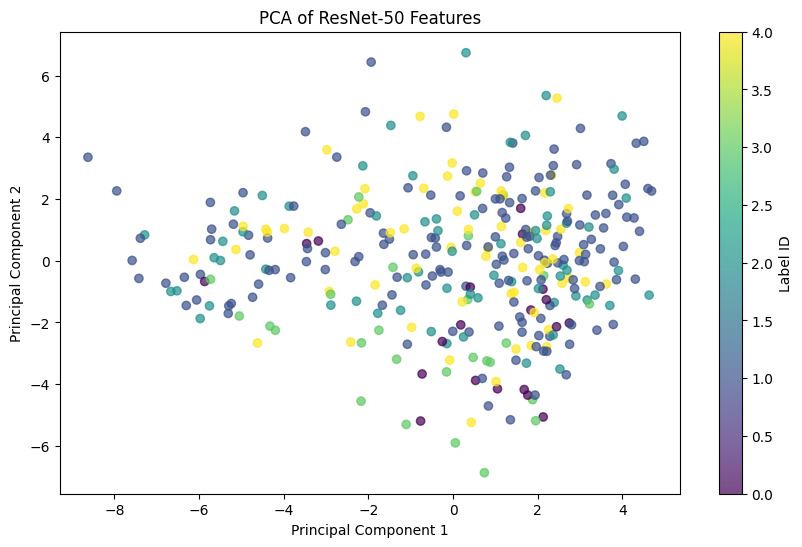

In [4]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(features)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Label ID')
plt.title('PCA of ResNet-50 Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


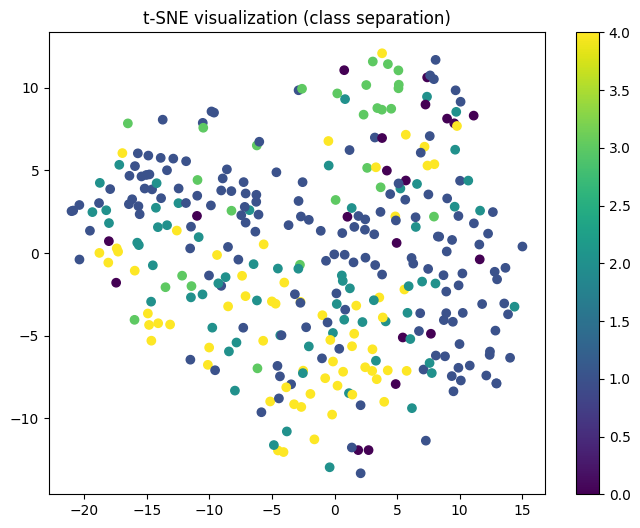

In [5]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
reduced = tsne.fit_transform(features)

plt.figure(figsize=(8,6))
scatter = plt.scatter(reduced[:,0], reduced[:,1], c=labels)

plt.title("t-SNE visualization (class separation)")
plt.colorbar(scatter)
plt.show()


c:\Users\nguye\OneDrive\Desktop\uni\Y2_Sem3\jupyter\practice_vscode\my_virtual_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


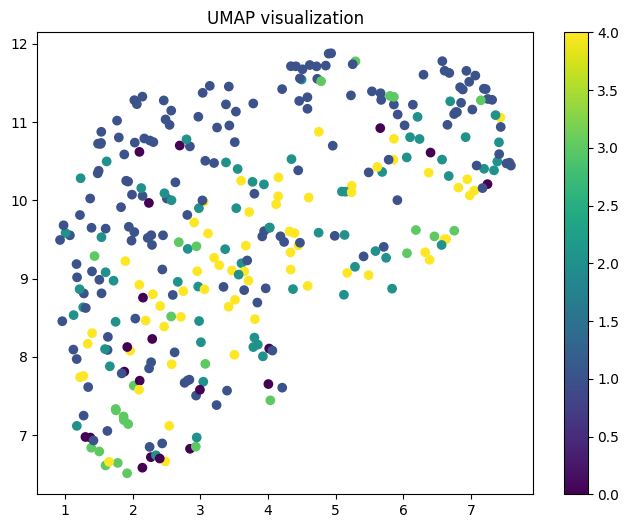

In [6]:
import umap

reducer = umap.UMAP()
reduced = reducer.fit_transform(features)

plt.figure(figsize=(8,6))
scatter = plt.scatter(reduced[:,0], reduced[:,1], c=labels)

plt.title("UMAP visualization")
plt.colorbar(scatter)
plt.show()